Mounted at /content/drive
데이터 형태: (455, 30) (455,) (114, 30) (114,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4571 - loss: 0.6667 - val_accuracy: 0.7281 - val_loss: 0.5355
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8923 - loss: 0.4425 - val_accuracy: 0.9211 - val_loss: 0.3489
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9538 - loss: 0.2614 - val_accuracy: 0.9298 - val_loss: 0.2113
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9538 - loss: 0.1597 - val_accuracy: 0.9211 - val_loss: 0.1621
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9648 - loss: 0.1200 - val_accuracy: 0.9386 - val_loss: 0.1405
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.0998 - val_accuracy: 0.9386 - val_loss: 0.1248
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9692 - loss: 0.0879 - val_accuracy: 0.9386 - val_loss: 0.1157
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9758 - loss: 0.0800 - val_accuracy: 0.9474 - val_loss

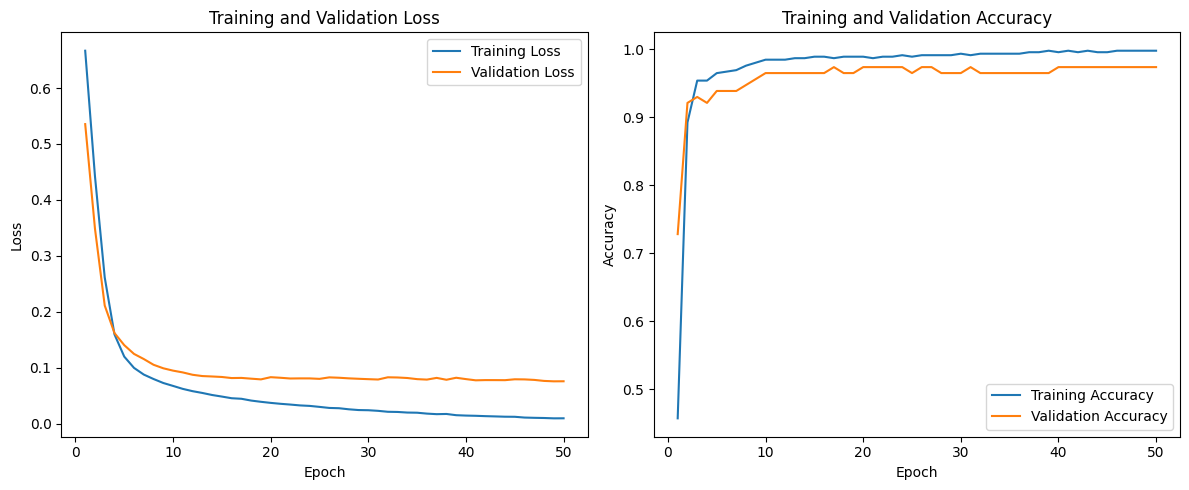


=== 최종 모델 평가 (evaluate) ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9737 - loss: 0.0760

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        47
           1       0.98      0.97      0.98        67

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Confusion Matrix ===
[[46  1]
 [ 2 65]]


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/breast_cancer.csv")

cancer = load_breast_cancer()
X_data = cancer.data
y = cancer.target

scaler = StandardScaler()
X = scaler.fit_transform(X_data)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("데이터 형태:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

model = Sequential()
model.add(Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

N_EPOCHS = 50

history = model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=16, validation_data=(X_test, y_test), verbose=1)

y_pred_prob = model.predict(X_test)
y_pred_class = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, N_EPOCHS + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, N_EPOCHS + 1), history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, N_EPOCHS + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, N_EPOCHS + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== 최종 모델 평가 (evaluate) ===")
model.evaluate(X_test, y_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_class))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_class))